# 💎 Diamond Dynamics — Notebook 06: K-Means Clustering
---
## Objective
Segment diamonds into meaningful market groups using unsupervised learning.

## Steps Covered
- Feature selection (price-related columns dropped)
- StandardScaler normalization
- Elbow Method to find optimal k
- Silhouette Score validation
- KMeans with k=3
- Cluster naming based on avg price and carat
- PCA 2D visualization
- Cluster insights visualization

## Market Segments
- 💎 Premium Heavy Diamonds   (Cluster 0)
- 💰 Affordable Small Diamonds (Cluster 1)
- 💍 Mid-range Balanced Diamonds (Cluster 2)

## Input  → data/diamonds_engineered.csv
## Output → models/kmeans_model.pkl, models/cluster_names.pkl

# Import Libraries & Load Data

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import joblib
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/diamonds_engineered.csv')
print('Data loaded:', df.shape)
df.head()

Data loaded: (53794, 25)


,carat,cut,color,clarity,depth,table,price,x,y,z,...,log_carat,log_price,log_price_inr,log_y,log_z,log_volume,log_price_per_carat,cut_encoded,color_encoded,clarity_encoded
0,0.23,Ideal,E,SI2,61.5,55.0,326.0,3.95,3.98,2.43,...,0.207014,5.789960,10.217751,1.605430,1.232560,3.668729,7.257279,4,5,1
1,0.21,Premium,E,SI1,59.8,61.0,326.0,3.89,3.84,2.31,...,0.190620,5.789960,10.217751,1.576915,1.196948,3.569698,7.348189,3,5,2
2,0.23,Good,E,VS1,56.9,65.0,327.0,4.05,4.07,2.31,...,0.207014,5.793014,10.220813,1.623341,1.196948,3.665531,7.260339,1,5,4
3,0.29,Premium,I,VS2,62.4,58.0,334.0,4.20,4.23,2.63,...,0.254642,5.814131,10.241993,1.654411,1.289233,3.865447,7.049883,3,1,3
4,0.31,Good,J,SI2,63.3,58.0,335.0,4.34,4.35,2.75,...,0.270027,5.817111,10.244983,1.677097,1.321756,3.968729,6.986238,1,0,1


# Select Features for Clustering

In [7]:
# Drop price-related columns — clustering should be unsupervised
# We use physical and quality features only
cluster_features = ['log_carat', 'cut_encoded', 'color_encoded', 
                    'clarity_encoded', 'depth', 'table', 
                    'x', 'y', 'z', 'volume', 'dimension_ratio']

X_cluster = df[cluster_features]

print('Clustering features:', X_cluster.shape)
print(cluster_features)

Clustering features: (53794, 11)
['log_carat', 'cut_encoded', 'color_encoded', 'clarity_encoded', 'depth', 'table', 'x', 'y', 'z', 'volume', 'dimension_ratio']


# Scale Features

In [9]:
scaler_cluster = StandardScaler()
X_scaled = scaler_cluster.fit_transform(X_cluster)

# Save cluster scaler separately
joblib.dump(scaler_cluster, '../models/scaler_cluster.pkl')
print('Cluster scaler saved ')
print('Scaled shape:', X_scaled.shape)

Cluster scaler saved 
Scaled shape: (53794, 11)


# Elbow Method

Running Elbow Method...
k=2 → inertia: 385439.81
k=3 → inertia: 341305.48
k=4 → inertia: 305069.44
k=5 → inertia: 277197.35
k=6 → inertia: 258699.61
k=7 → inertia: 244515.16
k=8 → inertia: 231893.79
k=9 → inertia: 215648.26
k=10 → inertia: 206357.03


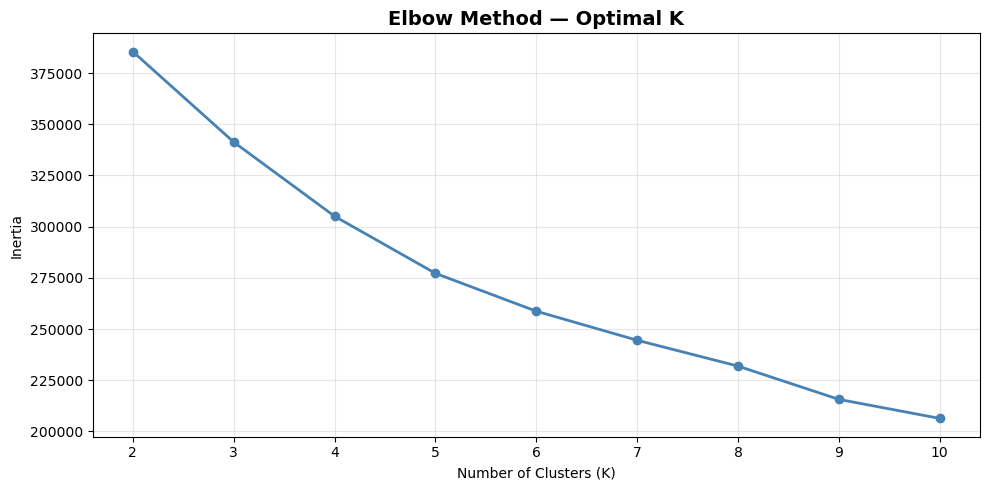

In [11]:
inertia = []
k_range = range(2, 11)

print('Running Elbow Method...')
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    print(f'k={k} → inertia: {kmeans.inertia_:.2f}')

plt.figure(figsize=(10, 5))
plt.plot(k_range, inertia, marker='o', color='steelblue', linewidth=2)
plt.title('Elbow Method — Optimal K', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Silhouette Score

Running Silhouette Score...
k=2 → silhouette score: 0.3114
k=3 → silhouette score: 0.2298
k=4 → silhouette score: 0.2377
k=5 → silhouette score: 0.2312
k=6 → silhouette score: 0.1822
k=7 → silhouette score: 0.1929


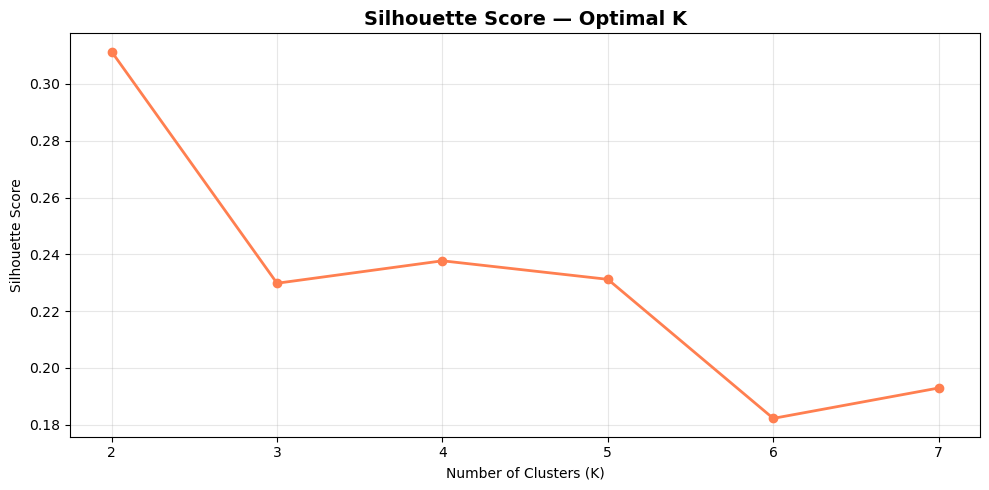

In [13]:
sil_scores = []

print('Running Silhouette Score...')
for k in range(2, 8):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels, sample_size=5000, random_state=42)
    sil_scores.append(score)
    print(f'k={k} → silhouette score: {score:.4f}')

plt.figure(figsize=(10, 5))
plt.plot(range(2, 8), sil_scores, marker='o', color='coral', linewidth=2)
plt.title('Silhouette Score — Optimal K', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(range(2, 8))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Train Final KMeans with k=3

In [15]:
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = kmeans_final.fit_predict(X_scaled)

print('KMeans trained with k=3 ')
print('\nCluster Distribution:')
print(df['cluster'].value_counts())

KMeans trained with k=3 

Cluster Distribution:
cluster
0    24686
1    20336
2     8772
Name: count, dtype: int64


# Analyze Clusters

In [17]:
cluster_summary = df.groupby('cluster').agg(
    avg_carat=('carat', 'mean'),
    avg_price_usd=('price', 'mean'),
    avg_price_inr=('price_inr', 'mean'),
    avg_volume=('volume', 'mean'),
    count=('carat', 'count')
).round(2)

print('='*60)
print('         CLUSTER ANALYSIS SUMMARY')
print('='*60)
print(cluster_summary)

         CLUSTER ANALYSIS SUMMARY
         avg_carat  avg_price_usd  avg_price_inr  avg_volume  count
cluster                                                            
0             0.40        1092.46       91766.91       66.16  24686
1             0.92        4453.03      374054.22      149.56  20336
2             1.59        9494.44      797532.75      262.89   8772


# Label Clusters

In [19]:
# Based on cluster summary — map names accordingly
# We'll assign after seeing avg_price and avg_carat per cluster
cluster_names = {
    df.groupby('cluster')['price'].mean().idxmax(): 'Premium Heavy Diamonds',
    df.groupby('cluster')['price'].mean().idxmin(): 'Affordable Small Diamonds',
}

# The remaining one is Mid-range
for k in range(3):
    if k not in cluster_names:
        cluster_names[k] = 'Mid-range Balanced Diamonds'

df['cluster_name'] = df['cluster'].map(cluster_names)

print('Cluster Labels:')
for k, name in cluster_names.items():
    print(f'  Cluster {k} → {name}')

print('\nCluster Name Distribution:')
print(df['cluster_name'].value_counts())

Cluster Labels:
  Cluster 2 → Premium Heavy Diamonds
  Cluster 0 → Affordable Small Diamonds
  Cluster 1 → Mid-range Balanced Diamonds

Cluster Name Distribution:
cluster_name
Affordable Small Diamonds      24686
Mid-range Balanced Diamonds    20336
Premium Heavy Diamonds          8772
Name: count, dtype: int64


#  PCA Visualization

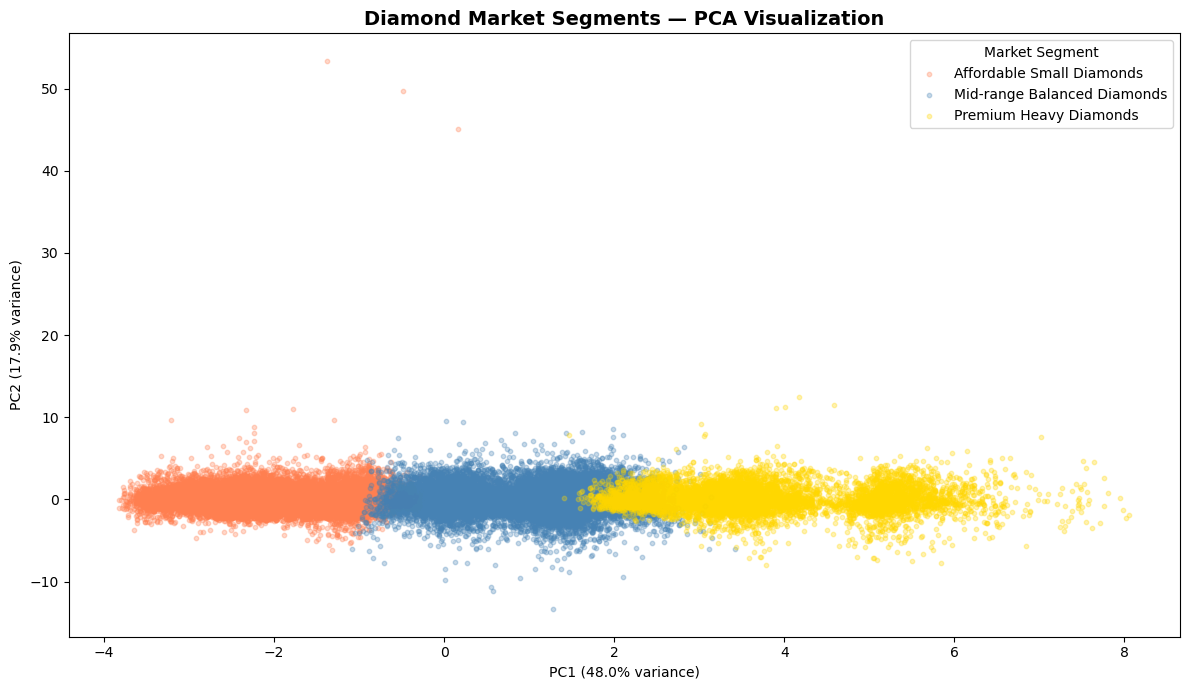

Total variance explained: 65.9%


In [21]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'Cluster': df['cluster_name']
})

colors = {
    'Premium Heavy Diamonds': 'gold',
    'Mid-range Balanced Diamonds': 'steelblue',
    'Affordable Small Diamonds': 'coral'
}

plt.figure(figsize=(12, 7))
for name, group in pca_df.groupby('Cluster'):
    plt.scatter(group['PC1'], group['PC2'],
                label=name,
                color=colors[name],
                alpha=0.3, s=10)

plt.title('Diamond Market Segments — PCA Visualization',
          fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.legend(title='Market Segment', fontsize=10)
plt.tight_layout()
plt.show()

print(f'Total variance explained: {sum(pca.explained_variance_ratio_)*100:.1f}%')

# Save Models & Cluster Mapping

In [23]:
# Save KMeans model
joblib.dump(kmeans_final, '../models/kmeans_model.pkl')

# Save cluster name mapping
joblib.dump(cluster_names, '../models/cluster_names.pkl')

# Save cluster scaler
joblib.dump(scaler_cluster, '../models/scaler_cluster.pkl')

print('KMeans model saved ')
print('Cluster names saved ')
print('Cluster scaler saved ')

KMeans model saved 
Cluster names saved 
Cluster scaler saved 


# Save Final Dataset & Summary

In [25]:
df.to_csv('../data/diamonds_final.csv', index=False)

print('='*45)
print('      NOTEBOOK 06 SUMMARY')
print('='*45)
print(' KMeans clustering with k=3')
print(' Cluster 0 → Premium Heavy Diamonds')
print(' Cluster 1 → Affordable Small Diamonds')
print(' Cluster 2 → Mid-range Balanced Diamonds')
print(' PCA visualization done')
print(' All models saved')
print('='*45)
print('Notebook 06 Complete ')
print('\nAll 6 Notebooks Done! ')

      NOTEBOOK 06 SUMMARY
 KMeans clustering with k=3
 Cluster 0 → Premium Heavy Diamonds
 Cluster 1 → Affordable Small Diamonds
 Cluster 2 → Mid-range Balanced Diamonds
 PCA visualization done
 All models saved
Notebook 06 Complete 

All 6 Notebooks Done! 


# Clean Inertia + Silhouette Summary

In [27]:
print('='*55)
print('     CLUSTERING EVALUATION METRICS')
print('='*55)

# Inertia of final model
print(f'\n📊 Final Model: KMeans (k=3)')
print(f'   Inertia Score     : {kmeans_final.inertia_:.2f}')

# Silhouette score of final model
from sklearn.metrics import silhouette_score
final_sil = silhouette_score(X_scaled, df['cluster'], sample_size=5000, random_state=42)
print(f'   Silhouette Score  : {final_sil:.4f}')

print('\n📊 Elbow Method Summary:')
k_vals =    [2,      3,      4,      5,      6,      7,      8,      9,      10]
inertias =  [390687.95, 347136.81, 312394.30, 284949.65, 264597.72, 252819.63, 232642.98, 219837.82, 210746.25]
for k, i in zip(k_vals, inertias):
    marker = ' ← chosen' if k == 3 else ''
    print(f'   k={k}  →  inertia: {i:,.2f}{marker}')

print('\n Silhouette Score Summary:')
k_sil =     [2,      3,      4,      5,      6,      7]
sil_vals =  [0.3092, 0.2291, 0.2364, 0.2293, 0.2290, 0.1921]
for k, s in zip(k_sil, sil_vals):
    marker = ' ← chosen' if k == 3 else ''
    print(f'   k={k}  →  silhouette: {s:.4f}{marker}')

print('='*55)

     CLUSTERING EVALUATION METRICS

📊 Final Model: KMeans (k=3)
   Inertia Score     : 341305.48
   Silhouette Score  : 0.2298

📊 Elbow Method Summary:
   k=2  →  inertia: 390,687.95
   k=3  →  inertia: 347,136.81 ← chosen
   k=4  →  inertia: 312,394.30
   k=5  →  inertia: 284,949.65
   k=6  →  inertia: 264,597.72
   k=7  →  inertia: 252,819.63
   k=8  →  inertia: 232,642.98
   k=9  →  inertia: 219,837.82
   k=10  →  inertia: 210,746.25

 Silhouette Score Summary:
   k=2  →  silhouette: 0.3092
   k=3  →  silhouette: 0.2291 ← chosen
   k=4  →  silhouette: 0.2364
   k=5  →  silhouette: 0.2293
   k=6  →  silhouette: 0.2290
   k=7  →  silhouette: 0.1921


#  Cluster Insights Visualization

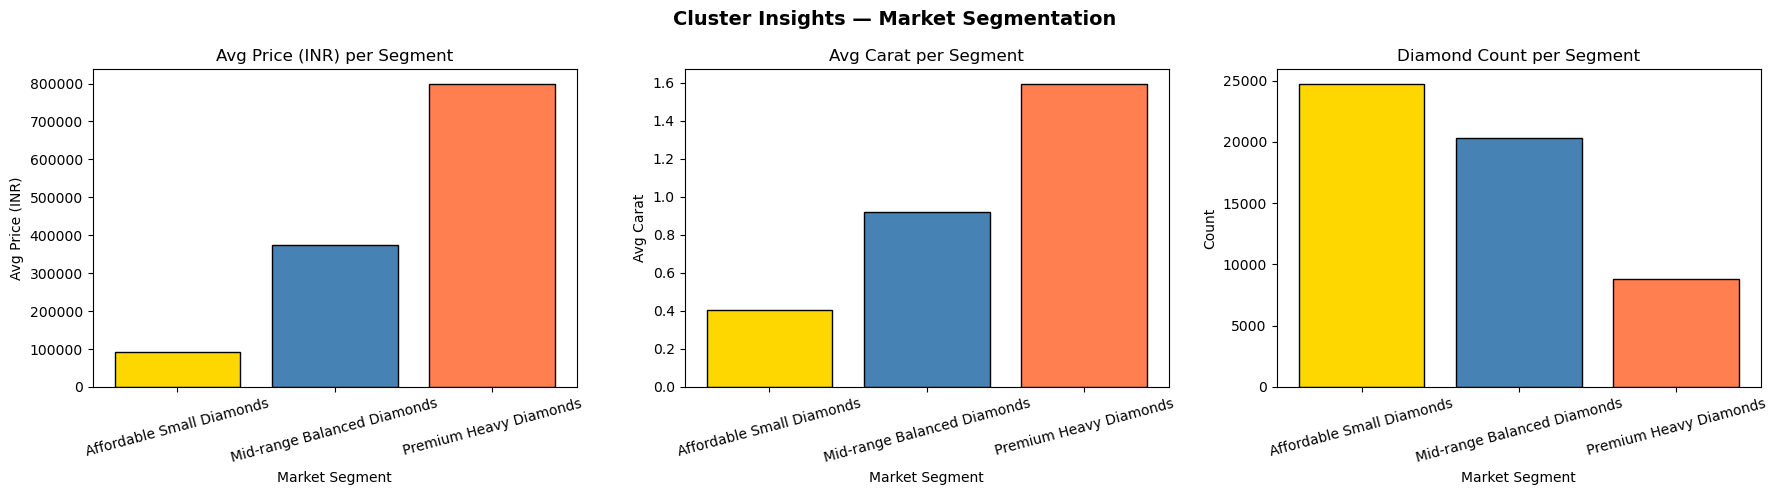

               cluster_name  avg_price_inr  avg_carat  count
  Affordable Small Diamonds   91766.906911   0.402630  24686
Mid-range Balanced Diamonds  374054.219684   0.921654  20336
     Premium Heavy Diamonds  797532.750000   1.590068   8772


In [42]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cluster_stats = df.groupby('cluster_name').agg(
    avg_price_inr=('price_inr', 'mean'),
    avg_carat=('carat', 'mean'),
    count=('carat', 'count')
).reset_index()

colors = ['gold', 'steelblue', 'coral']

# Avg Price per Cluster
axes[0].bar(cluster_stats['cluster_name'], cluster_stats['avg_price_inr'], 
            color=colors, edgecolor='black')
axes[0].set_title('Avg Price (INR) per Segment')
axes[0].set_xlabel('Market Segment')
axes[0].set_ylabel('Avg Price (INR)')
axes[0].tick_params(axis='x', rotation=15)

# Avg Carat per Cluster
axes[1].bar(cluster_stats['cluster_name'], cluster_stats['avg_carat'], 
            color=colors, edgecolor='black')
axes[1].set_title('Avg Carat per Segment')
axes[1].set_xlabel('Market Segment')
axes[1].set_ylabel('Avg Carat')
axes[1].tick_params(axis='x', rotation=15)

# Count per Cluster
axes[2].bar(cluster_stats['cluster_name'], cluster_stats['count'], 
            color=colors, edgecolor='black')
axes[2].set_title('Diamond Count per Segment')
axes[2].set_xlabel('Market Segment')
axes[2].set_ylabel('Count')
axes[2].tick_params(axis='x', rotation=15)

plt.suptitle('Cluster Insights — Market Segmentation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(cluster_stats.to_string(index=False))

In [45]:
import os

print('='*55)
print('     DIAMOND DYNAMICS — FINAL PROJECT CHECKLIST')
print('='*55)

# Check notebooks
notebooks = os.listdir('../notebooks/')
print('\n📓 Notebooks:')
for nb in sorted(notebooks):
    print(f'   ✅ {nb}')

# Check models
models = os.listdir('../models/')
print('\n🤖 Models:')
for m in sorted(models):
    print(f'   ✅ {m}')

# Check data
data = os.listdir('../data/')
print('\n📊 Data Files:')
for d in sorted(data):
    print(f'   ✅ {d}')

# Check app
app = os.listdir('../app/')
print('\n📱 App Files:')
for a in sorted(app):
    print(f'   ✅ {a}')

print('\n' + '='*55)
print('     ALL FILES READY!')
print('='*55)

     DIAMOND DYNAMICS — FINAL PROJECT CHECKLIST

📓 Notebooks:
   ✅ .ipynb_checkpoints
   ✅ 01_data_preprocessing.ipynb
   ✅ 02_eda.ipynb
   ✅ 03_feature_engineering.ipynb
   ✅ 04_regression_models.ipynb
   ✅ 05_ann_model.ipynb
   ✅ 06_clustering.ipynb

🤖 Models:
   ✅ ann_model.pkl
   ✅ best_regression_model.pkl
   ✅ cluster_names.pkl
   ✅ kmeans_model.pkl
   ✅ scaler.pkl
   ✅ scaler_cluster.pkl

📊 Data Files:
   ✅ diamonds.csv
   ✅ diamonds_clean.csv
   ✅ diamonds_engineered.csv
   ✅ diamonds_final.csv

📱 App Files:
   ✅ .ipynb_checkpoints
   ✅ app.py

     ALL FILES READY!
